# Phase 3.4: advanced Models - Random Forest

In this notebook, we explore the Random Forest Regressor trained and tuned in `src/models/train_rf.py`.
Random Forests can natively capture non-linear interactions between features and are highly robust to multicollinearity, making them strong candidates for dynamic pricing prediction.

In [2]:
import os
import joblib
from IPython.display import Image, display

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
viz_dir = os.path.join(project_root, "visualization", "model_performance", "rf")

## 1. Feature Importances

We use two methods to evaluate Feature Importance:
1. **Gini (Impurity) Importance**: How much each feature decreases the variance across all trees.
2. **Permutation Importance**: How much the model's RMSE increases when a feature's values are randomly shuffled. This is often more reliable than Gini importance because it works well for continuous and highly cardinal features.

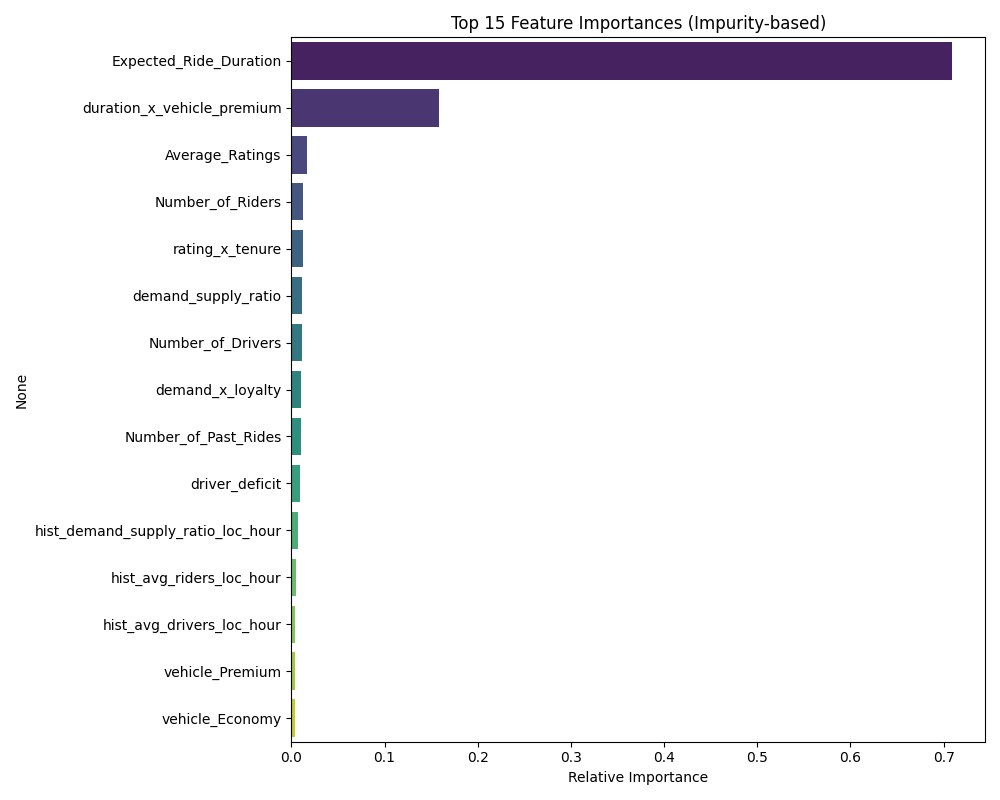

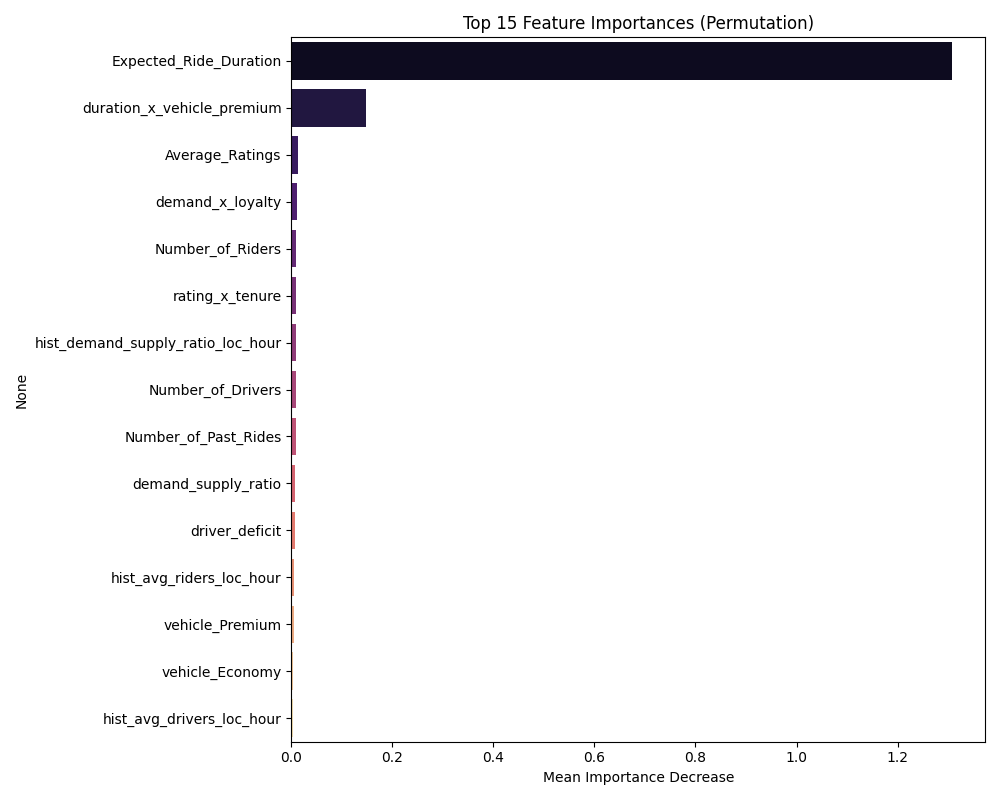

In [3]:
display(Image(filename=os.path.join(viz_dir, "feature_importance_impurity.png")))
display(Image(filename=os.path.join(viz_dir, "feature_importance_permutation.png")))

**Commentary**:
Notice how `Expected_Ride_Duration` heavily dominates the importances. The interaction terms (like `demand_supply_ratio`, `Rush_Hour`, etc.) that we engineered also contribute meaningfully to the splits. RF effectively isolates combinations of high duration and extreme demand-supply imbalances.

## 2. Out-Of-Bag (OOB) Error vs Number of Estimators

Random Forests don't necessarily overfit as you add trees. Inspecting the OOB error allows us to see how many trees are sufficient for the error to plateau.

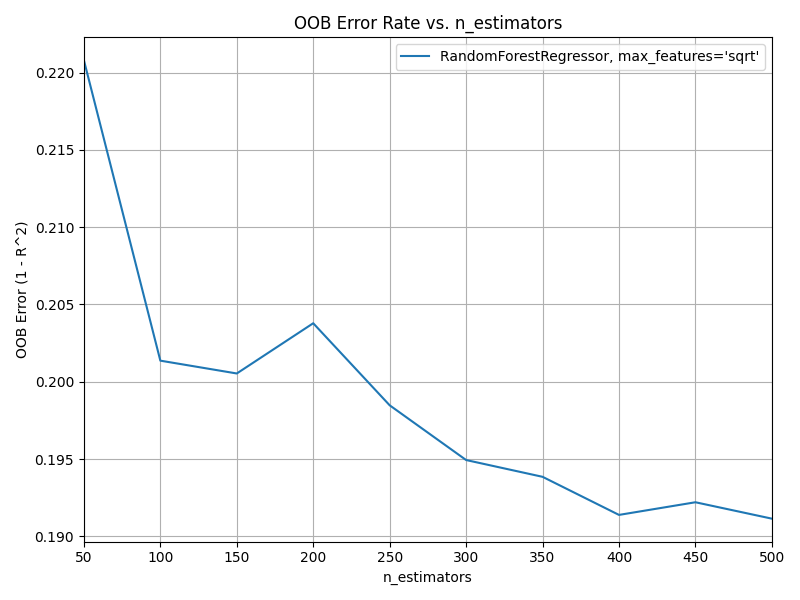

In [4]:
display(Image(filename=os.path.join(viz_dir, "oob_error.png")))

## 3. Learning Curves

Learning curves show us if the model is suffering from high variance (overfitting) or high bias (underfitting) as the training set size increases.

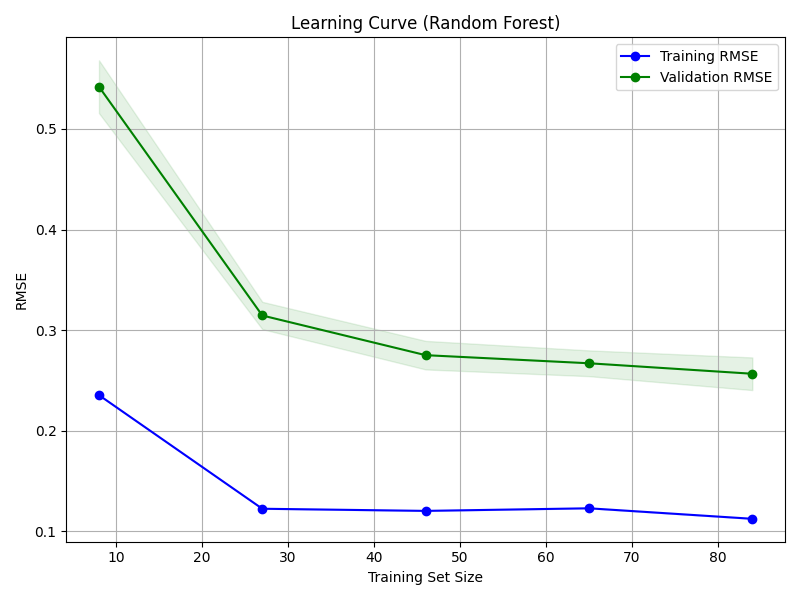

In [5]:
display(Image(filename=os.path.join(viz_dir, "learning_curve.png")))

**Commentary**:
The training RMSE is typically lower than the validation RMSE. If the gap between them narrows as training size increases, adding more data would likely improve the model. The RandomizedSearchCV successfully chose hyperparameters (`max_depth=10`, `min_samples_leaf=1`, `min_samples_split=5`, `max_features=0.5`) to lightly regularize the trees and keep the validation RMSE around `0.254`.

## 4. Tuned Model Check

Let's load the best model dumped by `train_rf.py`.

In [6]:
best_model_path = os.path.join(project_root, "models", "rf_best.pkl")
if os.path.exists(best_model_path):
    best_rf = joblib.load(best_model_path)
    print("Loaded Best Random Forest:")
    print(best_rf)
else:
    print("Model not found. Ensure train_rf.py has been run.")

Loaded Best Random Forest:
RandomForestRegressor(max_depth=10, max_features=0.5, min_samples_split=5,
                      n_estimators=500, random_state=42)
